# Stock prediction using neural networks

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from itertools import product
import matplotlib.pyplot as plt

## Data extraction and feature engineering

In [2]:
def generate_features(df):
    df_new = pd.DataFrame()
    # 6 original features
    df_new['open'] = df['Open']
    df_new['open_1'] = df['Open'].shift(1)
    df_new['close_1'] = df['Close'].shift(1)
    df_new['high_1'] = df['High'].shift(1)
    df_new['low_1'] = df['Low'].shift(1)
    df_new['volume_1'] = df['Volume'].shift(1)
    # 31 generated features
    # average price
    df_new['avg_price_5'] = df['Close'].rolling(5).mean().shift(1)
    df_new['avg_price_30'] = df['Close'].rolling(21).mean().shift(1)
    df_new['avg_price_365'] = df['Close'].rolling(252).mean().shift(1)
    df_new['ratio_avg_price_5_30'] = df_new['avg_price_5'] / df_new['avg_price_30']
    df_new['ratio_avg_price_5_365'] = df_new['avg_price_5'] / df_new['avg_price_365']
    df_new['ratio_avg_price_30_365'] = df_new['avg_price_30'] / df_new['avg_price_365']
    # average volume
    df_new['avg_volume_5'] = df['Volume'].rolling(5).mean().shift(1)
    df_new['avg_volume_30'] = df['Volume'].rolling(21).mean().shift(1)
    df_new['avg_volume_365'] = df['Volume'].rolling(252).mean().shift(1)
    df_new['ratio_avg_volume_5_30'] = df_new['avg_volume_5'] / df_new['avg_volume_30']
    df_new['ratio_avg_volume_5_365'] = df_new['avg_volume_5'] / df_new['avg_volume_365']
    df_new['ratio_avg_volume_30_365'] = df_new['avg_volume_30'] / df_new['avg_volume_365']
    # standard deviation of prices
    df_new['std_price_5'] = df['Close'].rolling(5).std().shift(1)
    df_new['std_price_30'] = df['Close'].rolling(21).std().shift(1)
    df_new['std_price_365'] = df['Close'].rolling(252).std().shift(1)
    df_new['ratio_std_price_5_30'] = df_new['std_price_5'] / df_new['std_price_30']
    df_new['ratio_std_price_5_365'] = df_new['std_price_5'] / df_new['std_price_365']
    df_new['ratio_std_price_30_365'] = df_new['std_price_30'] / df_new['std_price_365']
    # standard deviation of volumes
    df_new['std_volume_5'] = df['Volume'].rolling(5).std().shift(1)
    df_new['std_volume_30'] = df['Volume'].rolling(21).std().shift(1)
    df_new['std_volume_365'] = df['Volume'].rolling(252).std().shift(1)
    df_new['ratio_std_volume_5_30'] = df_new['std_volume_5'] / df_new['std_volume_30']
    df_new['ratio_std_volume_5_365'] = df_new['std_volume_5'] / df_new['std_volume_365']
    df_new['ratio_std_volume_30_365'] = df_new['std_volume_30'] / df_new['std_volume_365']
    # # return
    df_new['return_1'] = ((df['Close'] - df['Close'].shift(1)) / df['Close'].shift(1)).shift(1)
    df_new['return_5'] = ((df['Close'] - df['Close'].shift(5)) / df['Close'].shift(5)).shift(1)
    df_new['return_30'] = ((df['Close'] - df['Close'].shift(21)) / df['Close'].shift(21)).shift(1)
    df_new['return_365'] = ((df['Close'] - df['Close'].shift(252)) / df['Close'].shift(252)).shift(1)
    df_new['moving_avg_5'] = df_new['return_1'].rolling(5).mean().shift(1)
    df_new['moving_avg_30'] = df_new['return_1'].rolling(21).mean().shift(1)
    df_new['moving_avg_365'] = df_new['return_1'].rolling(252).mean().shift(1)
    # the target
    df_new['close'] = df['Close']
    df_new = df_new.dropna(axis=0)
    return df_new

In [3]:
data_raw = pd.read_csv('DJI_synthetic_19880101_20191231.csv', index_col='Date')
data = generate_features(data_raw)
print(data.round(decimals=3).head(5))

               open   open_1  close_1   high_1    low_1     volume_1  \
Date                                                                   
1988-12-22  2162.43  2189.02  2185.52  2192.83  2180.58  127714278.0   
1988-12-23  2153.85  2162.43  2156.24  2168.59  2150.73  109606505.0   
1988-12-26  2173.88  2153.85  2147.56  2154.39  2141.17  144514608.0   
1988-12-27  2159.67  2173.88  2173.42  2177.39  2168.47   77969226.0   
1988-12-28  2173.98  2159.67  2160.26  2163.52  2157.10  152509653.0   

            avg_price_5  avg_price_30  avg_price_365  ratio_avg_price_5_30  \
Date                                                                         
1988-12-22     2140.286      2118.143       1923.092                 1.010   
1988-12-23     2146.182      2121.188       1923.875                 1.012   
1988-12-26     2155.050      2121.808       1924.511                 1.016   
1988-12-27     2165.380      2123.030       1925.263                 1.020   
1988-12-28     2164.600    

In [4]:
print(data_raw.head(5))

               Open     High      Low    Close     Volume  Adj Close
Date                                                                
1988-01-01  1951.19  1951.42  1942.52  1948.41  156131537    1948.41
1988-01-04  1950.69  1960.46  1946.47  1946.72  169081585    1946.72
1988-01-05  1962.43  1965.14  1957.66  1959.04  136792169    1959.04
1988-01-06  1991.82  1996.31  1980.50  1987.27  132920802    1987.27
1988-01-07  1984.25  1991.40  1978.81  1983.80  128756123    1983.80


In [5]:
start_train = '1988-01-01'
end_train = '2018-12-31'

start_test = '2019-01-01'
end_test = '2019-12-31'

data_train = data.loc[start_train:end_train]
X_train = data_train.drop('close', axis=1).values
y_train = data_train['close'].values

print(X_train.shape)
print(y_train.shape)

data_test = data.loc[start_test:end_test]
X_test = data_test.drop('close', axis=1).values
y_test = data_test['close'].values

print(X_test.shape)

(7559, 37)
(7559,)
(261, 37)


In [6]:
scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_train)
X_scaled_test  = scaler.transform(X_test)

In [7]:
X_train_t = torch.tensor(X_scaled_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train,        dtype=torch.float32).unsqueeze(1)
X_test_t  = torch.tensor(X_scaled_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,         dtype=torch.float32).unsqueeze(1)

n_features = X_train_t.shape[1]

## Model building

In [8]:
torch.manual_seed(42)

In [9]:
def build_model(hidden_size: int) -> nn.Module:
    return nn.Sequential(
        nn.Linear(n_features, hidden_size),
        nn.ReLU(),
        nn.Linear(hidden_size, 1),
    )

In [10]:
model = build_model(hidden_size=32)

## Vanilla training

In [11]:
def train_model(X_train, y_train, X_test, y_test, model, epochs, lr, patience=200, writer=None, hparams=None):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    best_val = float('inf')
    no_improve = 0

    for epoch in range(1, epochs + 1):
        # train step
        model.train()
        optimizer.zero_grad()
        loss = loss_fn(model(X_train), y_train)
        loss.backward()
        optimizer.step()

        # validation / early stopping 
        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_test), y_test).item()

        if writer:
            writer.add_scalar('Loss/train', loss.item(), epoch)
            writer.add_scalar('Loss/val', val_loss, epoch)

        if val_loss < best_val - 1e-9:
            best_val = val_loss
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    return best_val

In [12]:
writer = SummaryWriter('logs/vanilla_training')

In [13]:
train_model(X_train_t, y_train_t, X_test_t, y_test_t, model, epochs=500, lr=0.1, writer=writer)

2995193.5

In [14]:
%load_ext tensorboard
%tensorboard --logdir logs/vanilla_training

## Evaluation

In [15]:
model.eval()
with torch.no_grad():
    predictions = model(X_test_t).squeeze().numpy()

print(f'MSE: {mean_squared_error(y_test, predictions):.3f}')
print(f'MAE: {mean_absolute_error(y_test, predictions):.3f}')
print(f'R^2: {r2_score(y_test, predictions):.3f}')

MSE: 7126050.164
MAE: 2545.762
R^2: -2.200


## Hyperparameter tuning

In [16]:
HP_HIDDEN = [64, 32, 16]
HP_EPOCHS = [300, 1000]
HP_LEARNING_RATE = np.linspace(0.01, 0.4, 5).round(2).tolist()

In [17]:
session_num = 0
results = []

for hidden, epochs, lr in product(HP_HIDDEN, HP_EPOCHS, HP_LEARNING_RATE):
    run_name = f'run-{session_num}'
    logdir = f'logs/hparam_tuning/{run_name}'
    print(f'--- Starting trial: {run_name}  hidden={hidden}  epochs={epochs}  lr={lr}')

    writer = SummaryWriter(logdir)

    torch.manual_seed(42)
    model = build_model(hidden_size=hidden)
    best_val_mse = train_model(X_train_t, y_train_t, X_test_t, y_test_t, model, epochs=epochs, lr=lr, patience=200, writer=writer)

    model.eval()
    with torch.no_grad():
        pred = model(X_test_t).squeeze().numpy()

    r2  = r2_score(y_test, pred)
    mse = mean_squared_error(y_test, pred)

    # Log final scalars + hparams for TensorBoard HParams tab
    writer.add_hparams(
        {'hidden_size': hidden, 'epochs': epochs, 'learning_rate': lr},
        {'hparam/mse': mse, 'hparam/r2': r2},
    )
    results.append({
        'hidden': hidden, 'epochs': epochs, 'lr': lr,
        'mse': mse, 'r2': r2
    })
    writer.close()
    session_num += 1

--- Starting trial: run-0  hidden=64  epochs=300  lr=0.01
--- Starting trial: run-1  hidden=64  epochs=300  lr=0.11
--- Starting trial: run-2  hidden=64  epochs=300  lr=0.2
--- Starting trial: run-3  hidden=64  epochs=300  lr=0.3
--- Starting trial: run-4  hidden=64  epochs=300  lr=0.4
--- Starting trial: run-5  hidden=64  epochs=1000  lr=0.01
--- Starting trial: run-6  hidden=64  epochs=1000  lr=0.11
--- Starting trial: run-7  hidden=64  epochs=1000  lr=0.2
--- Starting trial: run-8  hidden=64  epochs=1000  lr=0.3
--- Starting trial: run-9  hidden=64  epochs=1000  lr=0.4
--- Starting trial: run-10  hidden=32  epochs=300  lr=0.01
--- Starting trial: run-11  hidden=32  epochs=300  lr=0.11
--- Starting trial: run-12  hidden=32  epochs=300  lr=0.2
--- Starting trial: run-13  hidden=32  epochs=300  lr=0.3
--- Starting trial: run-14  hidden=32  epochs=300  lr=0.4
--- Starting trial: run-15  hidden=32  epochs=1000  lr=0.01
--- Starting trial: run-16  hidden=32  epochs=1000  lr=0.11
--- Start

In [18]:
%tensorboard --logdir logs/hparam_tuning

## Best model

In [19]:
best = min(results, key=lambda x: x['mse'])
print(best)

{'hidden': 64, 'epochs': 1000, 'lr': 0.3, 'mse': 3744.189636117071, 'r2': 0.9983188140817755}


In [20]:
writer = SummaryWriter('logs/best_model')

In [21]:
torch.manual_seed(42)

In [22]:
model = build_model(hidden_size=best['hidden'])

In [23]:
train_model(X_train_t, y_train_t, X_test_t, y_test_t, model, epochs=best['epochs'], lr=best['lr'], writer=writer)

3744.193359375

In [24]:
model.eval()
with torch.no_grad():
    predictions = model(X_test_t).squeeze().numpy()

## Visualization

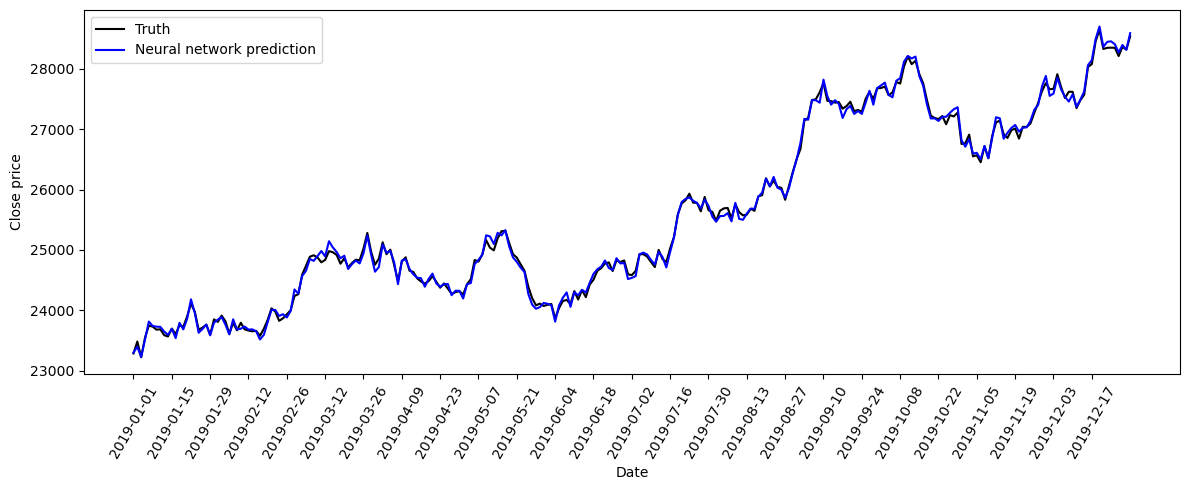

In [25]:
plt.figure(figsize=(12, 5))
plt.plot(data_test.index, y_test,      c='k', label='Truth')
plt.plot(data_test.index, predictions, c='b', label='Neural network prediction')
plt.xticks(range(0, 252, 10), rotation=60)
plt.xlabel('Date')
plt.ylabel('Close price')
plt.legend()
plt.tight_layout()
plt.show()